## Quantstats

In [34]:
import pandas as pd
%matplotlib inline
import quantstats as qs
file_name = "quantstats_report.html"

# fetch the daily returns for a stock
# stock = qs.utils.download_returns('FB')

# show sharpe ratio
# qs.stats.sharpe(stock)

# qs.plots.snapshot(stock, title='Facebook Performance')

# qs.reports.metrics(stock, "SPY", mode="full", compounded=False)
# qs.reports.metrics(stock, "SPY", mode="full")
# qs.reports.plots(stock, "SPY", mode="full")
# qs.reports.html(stock, "SPY", output=file_name)

In [35]:
from dateutil import parser
res = {}
for line in open("../../front/trades.csv", "r"):
    if "net_value" not in line:
        stats = line.strip().split(",")
        dt, val = stats[0], stats[8]
        res[parser.parse(dt)] = float(val)
stock = pd.Series(res)
stock.index.tz_localize("UTC")

stock.head(5)

2019-01-09 14:32:00    9990.37
2019-01-14 14:30:00    9939.29
2019-01-16 14:39:00    9838.97
2019-01-16 15:04:00    9857.93
2019-01-22 14:33:00    9829.97
dtype: float64

                           Strategy
-------------------------  ----------
Start Period               2019-01-09
End Period                 2021-08-24
Risk-Free Rate             0.0%
Time in Market             100.0%

Cumulative Return          160.11%
CAGR%                      43.94%

Sharpe                     2.58
Sortino                    7.99
Sortino/√2                 5.65

Max Drawdown               -7.94%
Longest DD Days            133
Volatility (ann.)          19.07%
Calmar                     5.53
Skew                       4.45
Kurtosis                   29.22

Expected Daily %           0.19%
Expected Monthly %         3.03%
Expected Yearly %          37.53%
Kelly Criterion            23.34%
Risk of Ruin               0.0%
Daily Value-at-Risk        -1.78%
Expected Shortfall (cVaR)  -1.78%

Gain/Pain Ratio            1.31
Gain/Pain (1M)             8.26

Payoff Ratio               2.51
Profit Factor              2.07
Common Sense Ratio         3.7
CPC Index               

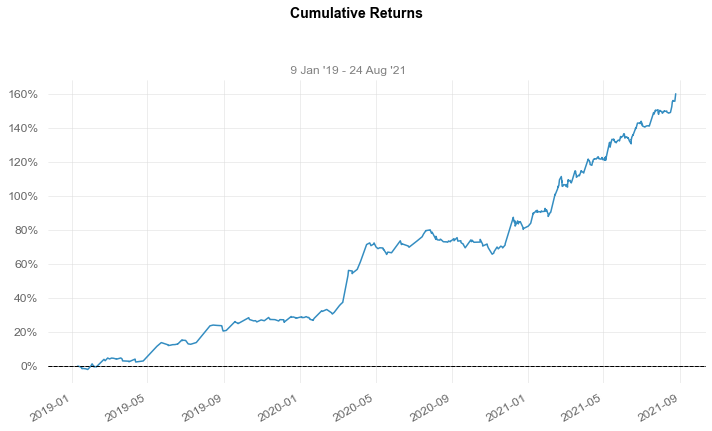

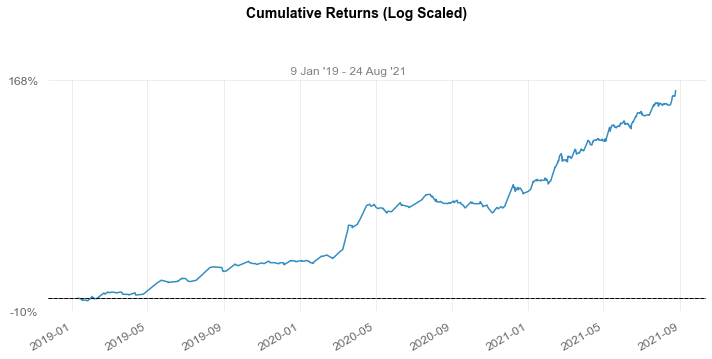

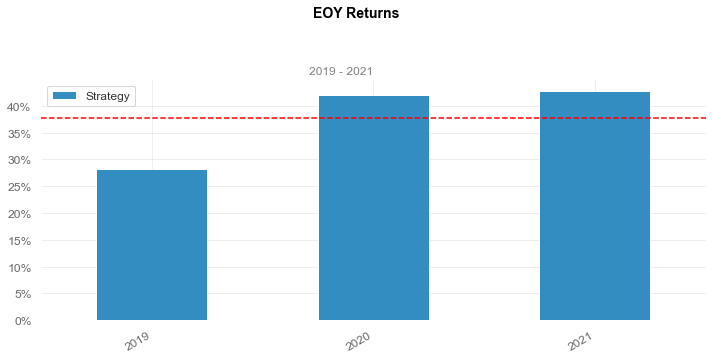

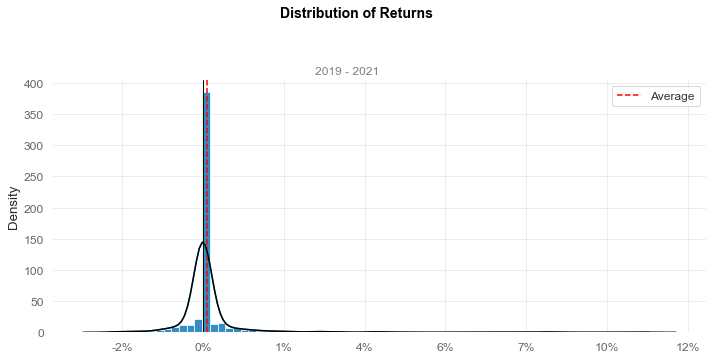

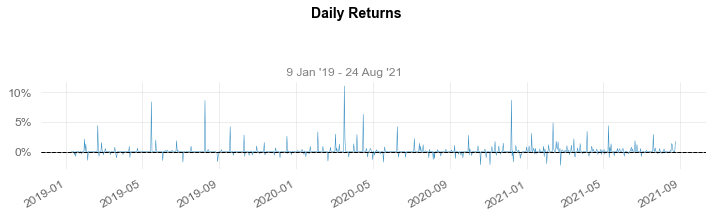

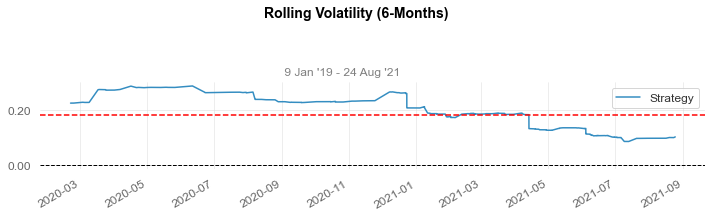

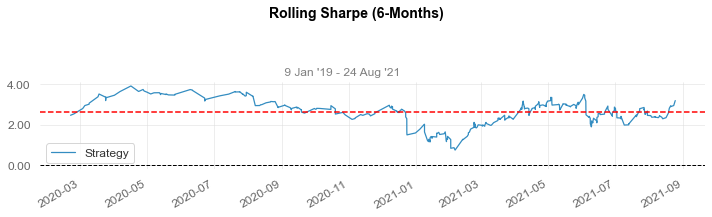

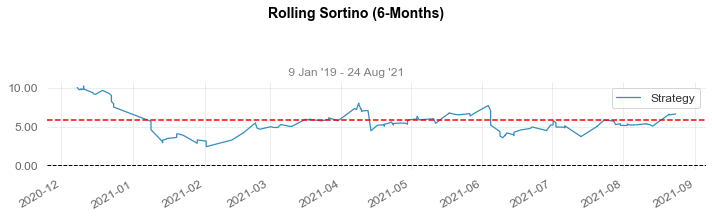

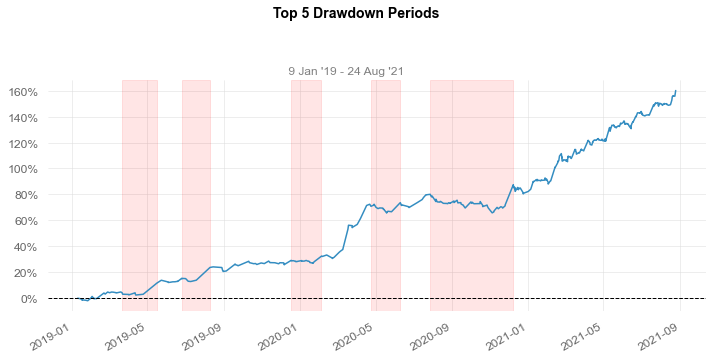

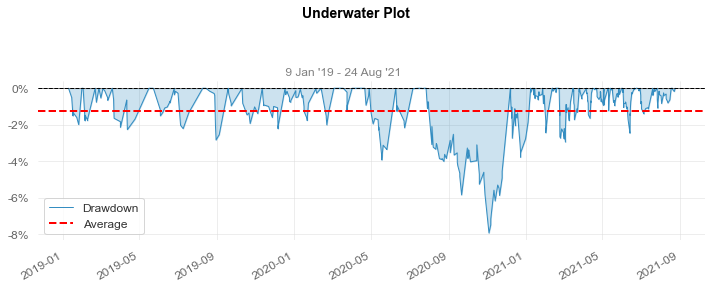

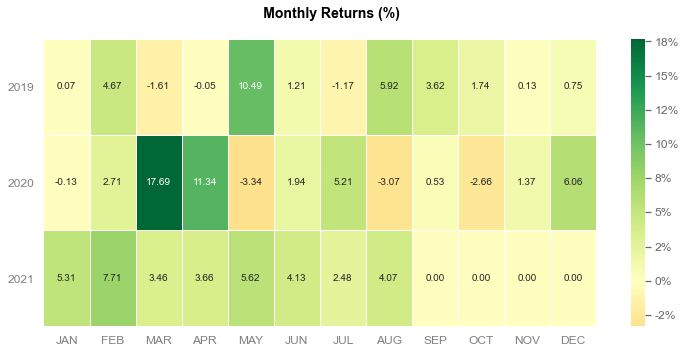

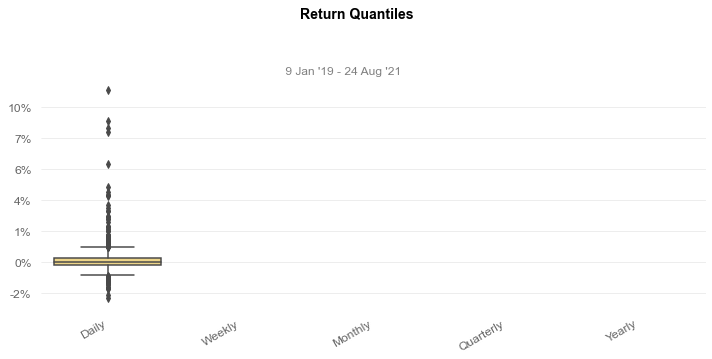

In [36]:
qs.reports.metrics(stock, mode="full", compounded=True)
qs.reports.plots(stock, mode="full", figsize=(10, 5))

In [37]:
qs.reports.html(stock, output=file_name)

import webbrowser, os
_ = webbrowser.open('file:///' + os.path.realpath(file_name))
